In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import svd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import trapezoid

# Класс для расчета S(w, w')

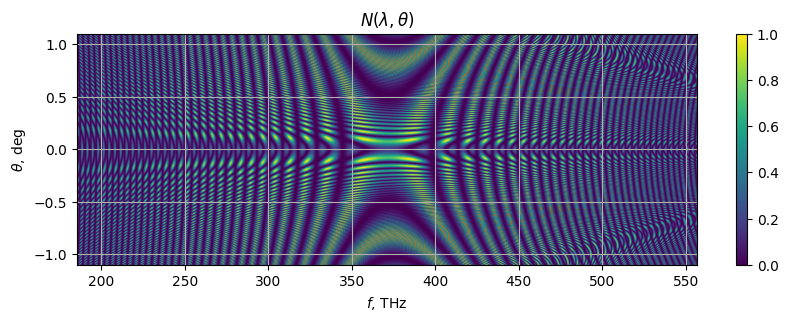

In [18]:
import numpy as np

c0 = 299_792_458.0  # m/s

# ----------------------------
# Refractive index placeholders
#
# LBO: https://unitedcrystals.com/LBOProp.html
# air: https://doi.org/10.1038/srep46111
# ----------------------------
def n_o(lambda_m):
    """Ordinary index n_o(λ) ~ n_y ~ n_z for LBO approximation."""
    lambda_um = lambda_m * 1e6
    # n2 = 2.586179 + 0.013099/(lambda_um**2-0.011893) - 0.017968*(lambda_um**2) - 2.26e-4*(lambda_um**4)  # Z LBO
    # n2 = 2.539070 + 0.012711/(lambda_um**2-0.012523) - 0.018540*(lambda_um**2) + 2.00e-4*(lambda_um**4)  # Y LBO
    lam2 = lambda_um**2
    n2 = (0.90291*lam2/(lam2 - 0.003926))+(0.83155*lam2/(lam2 - 0.018786))+(0.76536*lam2/(lam2 - 60.01)) + 1  # BBO
    return np.sqrt(n2)

def n_e(lambda_m):
    """Extraordinary principal index n_e(λ) ~ n_x for LBO approximation."""
    lambda_um = lambda_m * 1e6
    # n2 = 2.454140 + 0.011249/(lambda_um**2-0.011350) - 0.014591*(lambda_um**2) - 6.60e-5*(lambda_um**4)  # X
    lam2 = lambda_um**2
    n2 = (1.151075*lam2/(lam2 - 0.007142))+(0.21803*lam2/(lam2 - 0.02259))+(0.656*lam2/(lam2 - 263)) + 1  # BBO
    return np.sqrt(n2)

def n_air(lambda_m):
    """Refractvie index of the linear media in the gap"""
    lambda_um = lambda_m * 1e6

    B1 = 0.05792105
    B2 = 0.00167917
    C1 = 238.0185
    C2 = 57.362

    UV_1 = B1 / (C1 - 1/lambda_um**2)
    UV_2 = B2 / (C2 - 1/lambda_um**2)

    return 1 + UV_1 + UV_2

def snell_theta(n1, theta1, n2):
    """
    Snell: n1*sin(theta1) = n2*sin(theta2)
    Returns theta2 (NaN where no real solution).
    """
    sin2 = (n1/n2) * np.sin(theta1)
    bad = np.abs(sin2) > 1.0
    theta2 = np.full_like(theta1, np.nan, dtype=float)
    ok = ~bad
    theta2[ok] = np.arcsin(np.clip(sin2[ok], -1.0, 1.0))
    return theta2, bad


# ----------------------------
# Helpers
# ----------------------------
def omega_from_lambda(lambda_m):
    return 2*np.pi*c0/lambda_m

def lambda_from_omega(omega):
    return 2*np.pi*c0/omega

def k(omega, n):
    """Wavevector magnitude in a medium"""
    return n*omega/c0

def sinc(x):
    """sin(x)/x → 1 при x → 0"""
    x = np.asarray(x, float)
    y = np.ones_like(x)
    m = np.abs(x) > 1e-12
    y[m] = np.sin(x[m])/x[m]
    return y

def n_eff(n_o, n_e, psi):
    """
    Effective extraordinary index for uniaxial approximation:
      1/neff^2 = cos^2(psi)/n_e^2 + sin^2(psi)/n_o^2
    psi: angle between k_p and optic axis.
    """
    c2 = np.cos(psi)**2
    s2 = np.sin(psi)**2
    inv = c2/(n_e**2) + s2/(n_o**2)
    return 1/np.sqrt(inv)


# ------------------------------------
# Core: compute delta and delta'
# ------------------------------------
def phase_mismatch(omega_s, theta_s, lambda_p, psi_p, L, Lgap):
    """
    omega_s, theta_s: 2D meshes (same shape), INTERNAL angles in crystal.
    Returns:
      delta   = Δ*L   (crystal)
      deltap  = Δ'*Lgap (air gap)
      mask_invalid: True where geometry is not physical (no real idler angle)
    """
    omega_p = omega_from_lambda(lambda_p)
    omega_i = omega_p - omega_s

    # wavelengths
    lam_s = lambda_from_omega(omega_s)
    lam_i = lambda_from_omega(omega_i)
    lam_p = np.full_like(omega_s, lambda_p, dtype=float)

    # indices in crystal: type-I e->oo
    n_os = n_o(lam_s)
    n_oi = n_o(lam_i)
    n_op = n_o(lam_p)
    n_ep = n_e(lam_p)
    n_peff = n_eff(n_op, n_ep, psi_p)

    # wavevectors in crystal
    ks = k(omega_s, n_os)
    ki = k(omega_i, n_oi)
    kp = k(np.full_like(omega_s, omega_p), n_peff)

    # idler angle from transverse momentum conservation: ks sinθs = ks sinθi
    sin_ti = (ks/ki)*np.sin(theta_s)
    mask_invalid = np.abs(sin_ti) > 1.0
    theta_i = np.full_like(theta_s, np.nan, dtype=float)
    ok = ~mask_invalid
    theta_i[ok] = np.arcsin(np.clip(sin_ti[ok], -1.0, 1.0))

    # Δ in crystal: kp - ks cosθs - ks cosθi
    Delta = kp - ks*np.cos(theta_s) - ki*np.cos(theta_i)
    delta = Delta*L

    # ---- gap (air): use Snell to convert theta_s(crystal) -> theta_s(air) ----
    ns_a = n_air(lam_s)
    ni_a = n_air(lam_i)
    np_a = n_air(lam_p)

    # signal angle in air (gap) from Snell: n_o*sin(theta_cr) = n_air*sin(theta_air)
    theta_s_air, bad_snell_s = snell_theta(n_os, theta_s, ns_a)

    # wavevectors in air
    ks_a = k(omega_s, ns_a)
    ki_a = k(omega_i, ni_a)
    kp_a = k(np.full_like(omega_s, omega_p), np_a)

    # idler angle in air from transverse matching in air
    sin_ti_a = (ks_a/ki_a) * np.sin(theta_s_air)
    mask_invalid_a = np.abs(sin_ti_a) > 1.0
    theta_i_a = np.full_like(theta_s, np.nan, dtype=float)
    ok_a = ~(mask_invalid_a | bad_snell_s | np.isnan(theta_s_air))
    theta_i_a[ok_a] = np.arcsin(np.clip(sin_ti_a[ok_a], -1.0, 1.0))

    # longitudinal mismatch in air
    Delta_a = kp_a - ks_a*np.cos(theta_s_air) - ki_a*np.cos(theta_i_a)
    delta_a = Delta_a * Lgap

    mask_invalid = mask_invalid | bad_snell_s | mask_invalid_a | (omega_i <= 0)
    return delta, delta_a, mask_invalid, Delta



# ------------------------------------
# g(ω,θ) and N(ω,θ) for n=2
# ------------------------------------
def g_N(delta, deltap, omega_s, omega_p, L):
    """
    For n=2 identical layers:
      g = { sinc(δ/2) * sin[2*(δ + δ')/2] / (2 * sin[(δ + δ')/2]) }² = { sinc(δ/2) * cos[(δ + δ')/2]) }²
      N ∝ (2𝜋 2L / c)² * ω * ω̃ * g
    """
    g = (sinc(delta/2) * np.cos(1/2 * (delta + deltap)))**2

    omega_p = np.full_like(omega_s, omega_p)
    omega_i = omega_p - omega_s
    N = (2*np.pi*2*L/c0)**2 * omega_s * omega_i * g
    return g, N


# ==========================
# Calculation of SPDC frequency-angular spectrum (Lgap=0)
# ==========================
# 1) define pump wavelength and geometry
lambda_p = 404e-9     # <- pump wavelength
psi_p = np.deg2rad(28.97)  # LBO orientation & uniaxial approx
# psi_p = np.deg2rad(29.77)  # LBO orientation & uniaxial approx
L = 2e-3              # 5 mm layer
Lgap = 53e-3           # air gap

# 2) build grids (signal frequency and internal angle in crystal)
omega_p = omega_from_lambda(lambda_p)
omega_grid = np.linspace(0.25*omega_p, 0.75*omega_p, 1000)          # rad/s
theta_grid = np.linspace(np.deg2rad(-1.1), np.deg2rad(1.1), 500)                # rad

OMG, TH = np.meshgrid(omega_grid, theta_grid, indexing="xy")

# 3) compute phases, then g and N
delta, deltap, invalid, Delta = phase_mismatch(OMG, TH, lambda_p, psi_p, L, Lgap)
g, N = g_N(delta, deltap, omega_grid, omega_p, L)

# mask non-physical points
g = np.where(invalid, np.nan, g)
N = np.where(invalid, np.nan, N)

# plot
lambda_grid_reverse = 2 * np.pi * c0 / omega_grid
N_lambda_dom = N * (2 * np.pi * c0) / lambda_grid_reverse**2
lambda_grid = lambda_grid_reverse[::-1]
N_lambda_dom = N_lambda_dom[:, ::-1]
N_plot = N_lambda_dom / N_lambda_dom.max()
plt.figure(figsize=(10, 3))
plt.imshow(N/N.max(), origin="lower", aspect="auto",
           extent=np.array([
               omega_grid[0]/(2*np.pi)/1e12, 
               omega_grid[-1]/(2*np.pi)/1e12, 
               np.rad2deg(theta_grid[0]), 
               np.rad2deg(theta_grid[-1])
           ]))
plt.xlabel(r"$f$, THz")
# plt.imshow(N_plot, origin="lower", aspect="auto",
#            extent=np.array([
#                lambda_grid[0]/1e-9, 
#                lambda_grid[-1]/1e-9, 
#                np.rad2deg(theta_grid[0]), 
#                np.rad2deg(theta_grid[-1])
#            ]))
# plt.contour(omega_grid/(2*np.pi)/1e12, np.rad2deg(theta_grid), Delta, levels=[0.0])
# plt.xlabel(r"$\lambda$, nm")
plt.ylabel(r"$\theta$, deg")
plt.title(r"$N(\lambda, \theta)$")
plt.colorbar()
plt.grid()
plt.show()

In [14]:
lambda_p = 404e-9     # <- pump wavelength
psi_p = np.deg2rad(29.0)  # LBO orientation & uniaxial approx
L = 1e-3              # 5 mm layer
Lgap = 0e-3           # air gap
psi_arr = np.deg2rad(np.linspace(29.5, 27.5, 200))

i = 0
for psi_p in psi_arr:
    omega_p = omega_from_lambda(lambda_p)
    omega_grid = np.linspace(0.25*omega_p, 0.75*omega_p, 1000)          # rad/s
    theta_grid = np.linspace(np.deg2rad(-3.0), np.deg2rad(3.0), 1000)                # rad
    
    OMG, TH = np.meshgrid(omega_grid, theta_grid, indexing="xy")
    
    # 3) compute phases, then g and N
    delta, deltap, invalid, Delta = phase_mismatch(OMG, TH, lambda_p, psi_p, L, Lgap)
    g, N = g_N(delta, deltap, omega_grid, omega_p, L)
    
    # mask non-physical points
    g = np.where(invalid, np.nan, g)
    N = np.where(invalid, np.nan, N)
    N = N / N.max()
    
    # plot
    fig, ax = plt.subplots(figsize=(6,4), dpi=120)
    ax.contour(omega_grid/(2*np.pi)/1e12, np.rad2deg(theta_grid), Delta, levels=[0.0])
    ax.set_xlabel(r"$f$, THz")
    ax.set_ylabel(r"$\theta$, deg")
    ax.set_title(fr"$\lambda_p={lambda_p*1e9:.1f} nm$, $\Delta'=0$ mm, $\psi={np.rad2deg(psi_p):.2f}^\circ$")

    fig.savefig(f"./frames_1/frame_{i:04d}.png", bbox_inches="tight")
    plt.close(fig)
    
    fig, ax = plt.subplots(figsize=(6,4), dpi=120)
    ax.imshow(N, origin="lower", aspect="auto",
               extent=np.array([
                   omega_grid[0]/(2*np.pi)/1e12, 
                   omega_grid[-1]/(2*np.pi)/1e12, 
                   np.rad2deg(theta_grid[0]), 
                   np.rad2deg(theta_grid[-1])
               ]))
    ax.set_xlabel(r"$f$, THz")
    ax.set_ylabel(r"$\theta$, deg")
    ax.set_title(fr"$\lambda_p={lambda_p*1e9:.1f} nm$, $\Delta'=0$ mm, $\psi={np.rad2deg(psi_p):.2f}^\circ$")

    fig.savefig(f"./frames_2/frame_{i:04d}.png", bbox_inches="tight")
    plt.close(fig)
    i += 1


import imageio.v2 as imageio
from pathlib import Path

frames_dir = Path("frames_1")
images = sorted(frames_dir.glob("frame_*.png"))

with imageio.get_writer("type1_sync_delta.gif", mode="I", duration=0.05, loop=0) as writer:
    for img in images:
        writer.append_data(imageio.imread(img))

print("GIF saved: type1_sync_delta.gif")


frames_dir = Path("frames_2")
images = sorted(frames_dir.glob("frame_*.png"))

with imageio.get_writer("type1_sync.gif", mode="I", duration=0.05, loop=0) as writer:
    for img in images:
        writer.append_data(imageio.imread(img))

print("GIF saved: type1_sync.gif")

GIF saved: type1_sync_delta.gif
GIF saved: type1_sync.gif


In [328]:
lambda_p = 405.9e-9     # <- pump wavelength
psi_p = np.deg2rad(28.97)  # LBO orientation & uniaxial approx
L = 5e-3              # 5 mm layer
Lgap = 0e-3           # air gap
psi_arr = np.deg2rad(np.linspace(29.5, 27.5, 100))
gap_arr = np.linspace(0.0, 30.0e-3, 300)

i = 0
for Lgap in gap_arr:
    omega_p = omega_from_lambda(lambda_p)
    omega_grid = np.linspace(0.45*omega_p, 0.55*omega_p, 1000)          # rad/s
    theta_grid = np.linspace(np.deg2rad(-1.1), np.deg2rad(1.1), 500)                # rad
    
    OMG, TH = np.meshgrid(omega_grid, theta_grid, indexing="xy")
    
    # 3) compute phases, then g and N
    delta, deltap, invalid, Delta = phase_mismatch(OMG, TH, lambda_p, psi_p, L, Lgap)
    g, N = g_N(delta, deltap, omega_grid, omega_p, L)
    
    # mask non-physical points
    g = np.where(invalid, np.nan, g)
    N = np.where(invalid, np.nan, N)
    
    
    # plot
    lambda_grid_reverse = 2 * np.pi * c0 / omega_grid
    N_lambda_dom = N * (2 * np.pi * c0) / lambda_grid**2
    lambda_grid = lambda_grid_reverse[::-1]
    N_lambda_dom = N_lambda_dom[:, ::-1]
    N_plot = N_lambda_dom / N_lambda_dom.max()
    
    fig, ax = plt.subplots(figsize=(10,4), dpi=120)
    # ax.imshow(N, origin="lower", aspect="auto",
    #            extent=np.array([
    #                omega_grid[0]/(2*np.pi)/1e12, 
    #                omega_grid[-1]/(2*np.pi)/1e12, 
    #                np.rad2deg(theta_grid[0]), 
    #                np.rad2deg(theta_grid[-1])
    #            ]))
    imag = ax.imshow(N_plot, origin="lower", aspect="auto",
               extent=np.array([
                   lambda_grid[0]/1e-9, 
                   lambda_grid[-1]/1e-9, 
                   np.rad2deg(theta_grid[0]), 
                   np.rad2deg(theta_grid[-1])
               ]))
    # ax.set_xlabel(r"$f$, THz")
    ax.set_xlabel(r"$\lambda$, nm")
    ax.set_ylabel(r"$\theta$, deg")
    ax.set_title(fr"$\lambda_p={lambda_p*1e9:.1f}$ nm, $\psi=28.96^\circ$, $l'={Lgap/1e-3:.2f}$ mm")
    fig.colorbar(imag, ax=ax)
    fig.savefig(f"./frames_3/frame_{i:04d}.png", bbox_inches="tight")
    plt.close(fig)
    i += 1


import imageio.v2 as imageio
from pathlib import Path

frames_dir = Path("frames_3")
images = sorted(frames_dir.glob("frame_*.png"))

with imageio.get_writer("type1_interference.gif", mode="I", duration=0.05, loop=0) as writer:
    for img in images:
        writer.append_data(imageio.imread(img))

print("GIF saved: type1_interference.gif")

GIF saved: type1_interference.gif


# BBO

In [4]:
import numpy as np

c0 = 299792458.0  # m/s

# ----------------------------
# Refractive index placeholders
#
# LBO: https://unitedcrystals.com/LBOProp.html
# air: https://doi.org/10.1038/srep46111
# ----------------------------
def n_o_LBO(lambda_m):
    """Ordinary index n_o(λ) ~ n_y ~ n_z for LBO approximation."""
    lambda_um = lambda_m * 1e6
    # n2 = 2.586179 + 0.013099/(lambda_um**2-0.011893) - 0.017968*(lambda_um**2) - 2.26e-4*(lambda_um**4)  # Z LBO
    n2 = 2.539070 + 0.012711/(lambda_um**2-0.012523) - 0.018540*(lambda_um**2) + 2.00e-4*(lambda_um**4)  # Y LBO
    return np.sqrt(n2)

def n_e_LBO(lambda_m):
    """Extraordinary principal index n_e(λ) ~ n_x for LBO approximation."""
    lambda_um = lambda_m * 1e6
    n2 = 2.454140 + 0.011249/(lambda_um**2-0.011350) - 0.014591*(lambda_um**2) - 6.60e-5*(lambda_um**4)  # X
    return np.sqrt(n2)
    
def n_o_BBO(lambda_m):
    """Ordinary refractive index n_o(λ) in BBO"""
    lambda_um = lambda_m * 1e6
    lam2 = lambda_um**2
    n2 = 2.7405 + 0.0184/(lam2-0.0179) - 0.0155*lam2
    # n2 = (0.90291*lam2/(lam2 - 0.003926))+(0.83155*lam2/(lam2 - 0.018786))+(0.76536*lam2/(lam2 - 60.01)) + 1  # BBO
    return np.sqrt(n2)

def n_e_BBO(lambda_m):
    """Extraordinary refractive index n_e(λ) in BBO"""
    lambda_um = lambda_m * 1e6
    lam2 = lambda_um**2
    n2 = 2.3730 + 0.0128/(lam2-0.0156) - 0.0044*lam2
    # n2 = (1.151075*lam2/(lam2 - 0.007142))+(0.21803*lam2/(lam2 - 0.02259))+(0.656*lam2/(lam2 - 263)) + 1  # BBO
    return np.sqrt(n2)

def n_eff(n_o, n_e, psi):
    """
    Effective extraordinary index for uniaxial approximation:
      1/neff^2 = cos^2(psi)/n_e^2 + sin^2(psi)/n_o^2
    psi: angle between k_p and optic axis (оптической осью или осью кристалла?).
    """
    c2 = np.cos(psi)**2
    s2 = np.sin(psi)**2
    inv = c2/(n_e**2) + s2/(n_o**2)
    return 1/np.sqrt(inv)

def n_air(lambda_m):
    """Refractvie index of the linear media in the gap"""
    lambda_um = lambda_m * 1e6

    B1 = 0.05792105
    B2 = 0.00167917
    C1 = 238.0185
    C2 = 57.362

    UV_1 = B1 / (C1 - 1/lambda_um**2)
    UV_2 = B2 / (C2 - 1/lambda_um**2)

    return 1 + UV_1 + UV_2

def n_o_caco3(lambda_m):
    """Ordinary refractive index of calcite (CaCO3)"""
    lambda_um = lambda_m * 1e6
    lam2 = lambda_um**2
    # n2 = 2.69705 + 0.0192064/((lambda_um**2)-0.01820) - 0.0151624*(lambda_um**2)
    n2 = 1 + 0.73358749 + 0.96464345*lam2/(lam2-1.94325203e-2) + 1.82831454*lam2/(lam2-120)
    return np.sqrt(n2)

def n_e_caco3(lambda_m):
    """Extraordinary refractive index of calcite (CaCO3)"""
    lambda_um = lambda_m * 1e6
    lam2 = lambda_um**2
    # n2 = 2.18438 + 0.0087309/((lambda_um**2)-0.01018) - 0.0024411*(lambda_um**2)
    n2 = 1 + 0.35859695 + 0.82427830*lam2/(lam2-1.06689543e-2) + 0.14429128*lam2/(lam2-120)
    return np.sqrt(n2)


# ----------------------------
# Helpers
# ----------------------------
def omega_from_lambda(lambda_m):
    return 2*np.pi*c0/lambda_m

def lambda_from_omega(omega):
    return 2*np.pi*c0/omega

def k(omega, n):
    """Wavevector magnitude in a medium"""
    return n*omega/c0

def sinc(x):
    """sin(x)/x → 1 при x → 0"""
    x = np.asarray(x, float)
    y = np.ones_like(x)
    m = np.abs(x) > 1e-12
    y[m] = np.sin(x[m])/x[m]
    return y
    

def snell_theta(n1, theta1, n2):
    """
    Snell: n1*sin(theta1) = n2*sin(theta2)
    Returns theta2 (NaN where no real solution).
    """
    sin2 = (n1/n2) * np.sin(theta1)
    bad = np.abs(sin2) > 1.0
    theta2 = np.full_like(theta1, np.nan, dtype=float)
    ok = ~bad
    theta2[ok] = np.arcsin(np.clip(sin2[ok], -1.0, 1.0))
    return theta2, bad


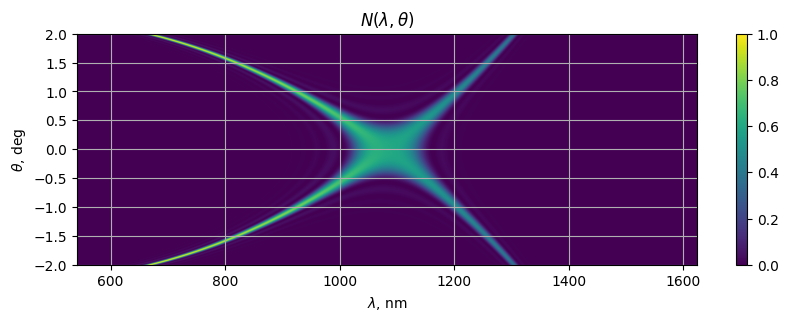

In [245]:
# mb delete
# ------------------------------------
# Core: compute delta and delta'
# ------------------------------------
def phase_mismatch(omega_s, theta_s, lambda_p, psi_p, L, Lgap):
    """
    omega_s, theta_s: 2D meshes (same shape), INTERNAL angles in crystal.
    Returns:
      delta   = Δ*L   (crystal)
      deltap  = Δ'*Lgap (air gap)
      mask_invalid: True where geometry is not physical (no real idler angle)
    """
    omega_p = omega_from_lambda(lambda_p)
    omega_i = omega_p - omega_s

    # wavelengths
    lam_s = lambda_from_omega(omega_s)
    lam_i = lambda_from_omega(omega_i)
    lam_p = np.full_like(omega_s, lambda_p, dtype=float)

    # indices in crystal: type-I e->oo
    n_os = n_o_LBO(lam_s)
    n_oi = n_o_LBO(lam_i)
    n_op = n_o_LBO(lam_p)
    n_ep = n_e_LBO(lam_p)
    n_peff = n_eff(n_op, n_ep, psi_p)

    # wavevectors in crystal
    ks = k(omega_s, n_os)
    ki = k(omega_i, n_oi)
    kp = k(np.full_like(omega_s, omega_p), n_peff)

    # idler angle from transverse momentum conservation: ks sinθs = ks sinθi
    sin_ti = (ks/ki)*np.sin(theta_s)
    mask_invalid = np.abs(sin_ti) > 1.0
    theta_i = np.full_like(theta_s, np.nan, dtype=float)
    ok = ~mask_invalid
    theta_i[ok] = np.arcsin(np.clip(sin_ti[ok], -1.0, 1.0))

    # Δ in crystal: kp - ks cosθs - ks cosθi
    Delta = kp - ks*np.cos(theta_s) - ki*np.cos(theta_i)
    delta = Delta*L

    # ---- gap (air): use Snell to convert theta_s(crystal) -> theta_s(air) ----
    ns_a = n_air(lam_s)
    ni_a = n_air(lam_i)
    np_a = n_air(lam_p)

    # signal angle in air (gap) from Snell: n_o*sin(theta_cr) = n_air*sin(theta_air)
    theta_s_air, bad_snell_s = snell_theta(n_os, theta_s, ns_a)

    # wavevectors in air
    ks_a = k(omega_s, ns_a)
    ki_a = k(omega_i, ni_a)
    kp_a = k(np.full_like(omega_s, omega_p), np_a)

    # idler angle in air from transverse matching in air
    sin_ti_a = (ks_a/ki_a) * np.sin(theta_s_air)
    mask_invalid_a = np.abs(sin_ti_a) > 1.0
    theta_i_a = np.full_like(theta_s, np.nan, dtype=float)
    ok_a = ~(mask_invalid_a | bad_snell_s | np.isnan(theta_s_air))
    theta_i_a[ok_a] = np.arcsin(np.clip(sin_ti_a[ok_a], -1.0, 1.0))

    # longitudinal mismatch in air
    Delta_a = kp_a - ks_a*np.cos(theta_s_air) - ki_a*np.cos(theta_i_a)
    delta_a = Delta_a * Lgap

    mask_invalid = mask_invalid | bad_snell_s | mask_invalid_a | (omega_i <= 0)
    return delta, delta_a, mask_invalid, Delta



# ------------------------------------
# g(ω,θ) and N(ω,θ) for n=2
# ------------------------------------
def g_N(delta, deltap, omega_s, omega_p, L):
    """
    For n=2 identical layers:
      g = { sinc(δ/2) * sin[2*(δ + δ')/2] / (2 * sin[(δ + δ')/2]) }² = { sinc(δ/2) * cos[(δ + δ')/2]) }²
      N ∝ (2𝜋 2L / c)² * ω * ω̃ * g
    """
    g = (sinc(delta/2) * np.cos(1/2 * (delta + deltap)))**2

    omega_p = np.full_like(omega_s, omega_p)
    omega_i = omega_p - omega_s
    N = (2*np.pi*2*L/c0)**2 * omega_s * omega_i * g
    return g, N


# ==========================
# Calculation of SPDC frequency-angular spectrum (Lgap=0)
# ==========================
# 1) define pump wavelength and geometry
lambda_p = 405.9e-9      # <- pump wavelength
psi_p = np.deg2rad(28.97)  # LBO orientation & uniaxial approx
L = 2.5e-3              # 5 mm layer
Lgap = 0e-3           # air gap

# 2) build grids (signal frequency and internal angle in crystal)
omega_p = omega_from_lambda(lambda_p)
omega_grid = np.linspace(0.25*omega_p, 0.75*omega_p, 1000)          # rad/s
theta_grid = np.linspace(np.deg2rad(-2), np.deg2rad(2), 5000)       # rad

OMG, TH = np.meshgrid(omega_grid, theta_grid, indexing="xy")

# 3) compute phases, then g and N
delta, deltap, invalid, Delta = phase_mismatch(OMG, TH, lambda_p, psi_p, L, Lgap)
g, N = g_N(delta, deltap, omega_grid, omega_p, L)

# mask non-physical points
g = np.where(invalid, np.nan, g)
N = np.where(invalid, np.nan, N)

# plot
lambda_grid_reverse = 2 * np.pi * c0 / omega_grid
N_lambda_dom = N * (2 * np.pi * c0) / lambda_grid_reverse**2
lambda_grid = lambda_grid_reverse[::-1]
N_lambda_dom = N_lambda_dom[:, ::-1]
N_plot = N_lambda_dom / N_lambda_dom.max()
plt.figure(figsize=(10, 3))
# plt.imshow(N/N.max(), origin="lower", aspect="auto",
#            extent=np.array([
#                omega_grid[0]/(2*np.pi)/1e12, 
#                omega_grid[-1]/(2*np.pi)/1e12, 
#                np.rad2deg(theta_grid[0]), 
#                np.rad2deg(theta_grid[-1])
#            ]))
plt.imshow(N_plot, origin="lower", aspect="auto",
           extent=np.array([
               lambda_grid[0]/1e-9, 
               lambda_grid[-1]/1e-9, 
               np.rad2deg(theta_grid[0]), 
               np.rad2deg(theta_grid[-1])
           ]))
# plt.contour(omega_grid/(2*np.pi)/1e12, np.rad2deg(theta_grid), Delta, levels=[0.0])
plt.xlabel(r"$\lambda$, nm")
plt.ylabel(r"$\theta$, deg")
plt.title(r"$N(\lambda, \theta)$")
plt.colorbar()
plt.grid()
plt.show()

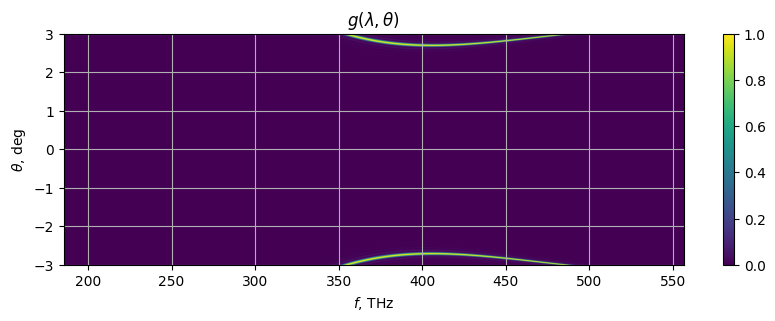

In [8]:
# Frequency-angular spectrum
# ==========================
# Calculation of NLI
# ==========================
# 1) define pump wavelength and geometry
lambda_p = 404e-9        # pump central wavelength
delta_lambda_p = 30.7e-12  # pump fwhm
psi_BBO = np.deg2rad(90 - 29.77375182)  # BBO orientation
L = 2e-3                # pump coherence length instead of the nonlinear media length
Lgap = 5.3e-2              # common air gap
d = 1.8e-3                # additional dispersive medium length

# 1.1) LBO
# lambda_p = 406e-9        # pump central wavelength
# delta_lambda_p = 5.5e-12  # pump fwhm
# psi_LBO = np.deg2rad(28.97)  # BBO orientation
# L = 2.5e-3                # pump coherence length instead of the nonlinear media length
# Lgap = 0e-3              # common air gap
# d = 0e-4                # additional dispersive medium length

# 2) build grids (signal frequency and internal angle in crystal)
omega_p = omega_from_lambda(lambda_p)
omega_grid = np.linspace(0.25*omega_p, 0.75*omega_p, 1000)          # rad/s
theta_grid = np.linspace(np.deg2rad(-3), np.deg2rad(3), 2000)       # rad

omega_grid_2D, theta_grid_2D = np.meshgrid(omega_grid, theta_grid, indexing="xy")

omega_s = omega_grid_2D
theta_s = theta_grid_2D

omega_p = omega_from_lambda(lambda_p)
omega_i = omega_p - omega_s

# 3) compute phase mismatch
# wavelengths
lam_s = lambda_from_omega(omega_s)
lam_i = lambda_from_omega(omega_i)
lam_p = np.full_like(omega_s, lambda_p, dtype=float)

# indices, type-I e->oo
n_s_o = n_o_BBO(lam_s)
n_i_o = n_o_BBO(lam_i)
n_p_o = n_o_BBO(lam_p)
n_p_e = n_e_BBO(lam_p)
n_p_eff = n_eff(n_p_o, n_p_e, psi_BBO)

n_s_air = n_air(lam_s)
n_i_air = n_air(lam_i)
n_p_air = n_air(lam_p)

n_s_caco3 = n_o_caco3(lam_s)
n_i_caco3 = n_o_caco3(lam_i)

# wavevectors
k_s_crystal = k(omega_s, n_s_o)
k_i_crystal = k(omega_i, n_i_o)
k_p_crystal = k(np.full_like(omega_s, omega_p), n_p_eff)

k_s_air = k(omega_s, n_s_air)
k_i_air = k(omega_i, n_i_air)
k_p_air = k(np.full_like(omega_s, omega_p), n_p_air)

k_s_caco3 =k(omega_s, n_s_caco3)
k_i_caco3 =k(omega_i, n_i_caco3)

# idler angle in crystal from momentum conservation: ks sinθs = ks sinθi
sin_ti = (k_s_crystal/k_i_crystal)*np.sin(theta_s)
theta_i = np.asin(sin_ti)
# mask_invalid = np.abs(sin_ti) > 1.0
# theta_i = np.full_like(theta_s, np.nan, dtype=float)
# ok = ~mask_invalid
# theta_i[ok] = np.arcsin(np.clip(sin_ti[ok], -1.0, 1.0))

# Δ in crystal: kp - ks cosθs - ks cosθi
Delta = k_p_crystal - k_s_crystal*np.cos(theta_s) - k_i_crystal*np.cos(theta_i)
delta = Delta*L

# signal angle in air gap from Snellius law: n_o*sin(theta_crystal) = n_air*sin(theta_air)
theta_s_air, bad_snell_s = snell_theta(n_s_o, theta_s, n_s_air)

# idler angle in air from transverse matching in air
sin_ti_air = (k_s_air/k_i_air) * np.sin(theta_s_air)
theta_i_air = np.asin(sin_ti_air)
# mask_invalid_a = np.abs(sin_ti_air) > 1.0
# theta_i_air = np.full_like(theta_s, np.nan, dtype=float)
# ok_a = ~(mask_invalid_a | bad_snell_s | np.isnan(theta_s_air))
# theta_i_air[ok_a] = np.arcsin(np.clip(sin_ti_air[ok_a], -1.0, 1.0))

# Δ in air
Delta_a = k_p_air - k_s_air*np.cos(theta_s_air) - k_i_air*np.cos(theta_i_air)
delta_a = Delta_a * Lgap

# signal angle in CaCO3: n_air*sin(theta_air) = n_caco3*sin(theta_caco3)
theta_s_caco3, bad_snell_s_caco3 = snell_theta(n_s_air, theta_s_air, n_s_caco3)

# idler angle in CaCO3 from transverse matching
sin_ti_caco3 = (k_s_caco3/k_i_caco3) * np.sin(theta_s_caco3)
theta_i_caco3 = np.asin(sin_ti_caco3)
# mask_invalid_caco3 = np.abs(sin_ti_caco3) > 1.0
# theta_i_caco3 = np.full_like(theta_s_caco3, np.nan, dtype=float)
# ok_caco3 = ~(mask_invalid_caco3 | bad_snell_s_caco3 | np.isnan(theta_s_caco3))  # !!
# theta_i_caco3[ok_caco3] = np.arcsin(np.clip(sin_ti_caco3[ok_caco3], -1.0, 1.0))

# Δ in CaCO3
# подобрать длину пробега накачки: x
x = d
delta_caco3 = k_p_air*x - k_s_caco3*np.cos(theta_s_caco3)*d - k_i_caco3*np.cos(theta_i_caco3)*d

# mask_invalid = mask_invalid | bad_snell_s | mask_invalid_a | bad_snell_s_caco3 | mask_invalid_caco3 | (omega_i <= 0)


# 4) compute instensity
# g, N = g_N(delta, deltap, omega_grid, omega_p, L)
omega_p = np.full_like(omega_s, omega_p)
delta_omega_p = (2 * np.pi * c0 / lambda_p**2) * delta_lambda_p

g = ( np.exp(-(omega_s + omega_i - omega_p)**2/(2*delta_omega_p**2)) * sinc(delta/2) * np.cos(1/2 * (delta + 0*delta_a + 0*delta_caco3)) )**2
"""
Тут нет смысла добавлять np.exp(-(omega_s + omega_i - omega_p)**2/(2*delta_omega_p**2)), т.к. она будет везде ноль.
Потому что сетка задается только по omega_s, а omega_i определеяется как раз из omega_i = omega_p - omega_s.
"""
N = (2*np.pi*2*L/c0)**2 * omega_s * omega_i * g

# mask non-physical points
# g = np.where(mask_invalid, np.nan, g)
# N = np.where(mask_invalid, np.nan, N)

# 5) plot
plt.figure(figsize=(10, 3))
plt.imshow(g/g.max(), origin="lower", aspect="auto",
           extent=np.array([
               omega_grid[0]/(2*np.pi)/1e12, 
               omega_grid[-1]/(2*np.pi)/1e12, 
               np.rad2deg(theta_grid[0]), 
               np.rad2deg(theta_grid[-1])
           ]))
plt.xlabel(r"$f$, THz")

# plt.figure(figsize=(10, 3))
# lambda_grid = (2 * np.pi * c0 / omega_grid)[::-1]
# g_lambda = g * omega_grid_2D**2 / (2 * np.pi * c0)
# g_lambda = g_lambda / g_lambda.max()
# plt.imshow(g_lambda, origin="lower", aspect="auto",
#            extent=np.array([
#                lambda_grid[0]/1e-9, 
#                lambda_grid[-1]/1e-9, 
#                np.rad2deg(theta_grid[0]), 
#                np.rad2deg(theta_grid[-1])
#            ]))
# plt.xlabel(r"$\lambda$, nm")

plt.ylabel(r"$\theta$, deg")
plt.title(r"$g(\lambda, \theta)$")
plt.colorbar()
plt.grid()
plt.show()

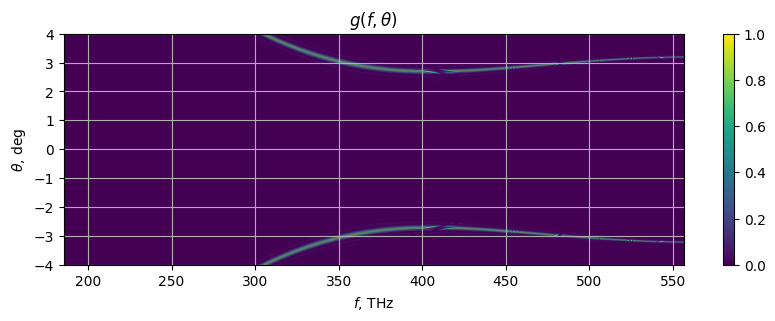

In [24]:
# Frequency-angular spectrum №2
# =========================
# Spectral-angular weight for SPDC in BBO
# with additional propagation through an air gap
# and a calcite plate
# =========================

# 1) Pump and geometry parameters
lambda_p = 404e-9                 # pump central wavelength, m
delta_lambda_p = 30.7e-12         # pump FWHM in wavelength, m
psi_BBO = np.deg2rad(90 - 29.77375182)   # BBO orientation angle
L = 2e-3                          # effective interaction/coherence length in BBO, m
d = 1.8e-3                        # calcite plate thickness, m
Lgap = 53e-3 - d                   # common air gap, m

# 1.1) Alternative LBO set of parameters
# lambda_p = 406e-9
# delta_lambda_p = 5.5e-12
# psi_LBO = np.deg2rad(28.97)
# L = 2.5e-3
# Lgap = 0e-3
# d = 0e-4

# 2) Working grid:
#    omega_s  - signal angular frequency
#    theta_s  - signal internal angle inside the nonlinear crystal
omega_p0 = omega_from_lambda(lambda_p)

omega_grid = np.linspace(0.25 * omega_p0, 0.75 * omega_p0, 1000)     # rad/s
theta_grid = np.linspace(np.deg2rad(-4), np.deg2rad(4), 1000)        # rad

omega_s, theta_s = np.meshgrid(omega_grid, theta_grid, indexing="xy")

# Idler frequency is restored from energy conservation:
# omega_s + omega_i = omega_p
omega_i = omega_p0 - omega_s

# Arrays with pump values on the same 2D grid
omega_p = np.full_like(omega_s, omega_p0)
lam_p = np.full_like(omega_s, lambda_p, dtype=float)

# 3) Material properties and longitudinal phase mismatch
# ------------------------------------------------------

# Wavelengths corresponding to signal and idler frequencies
lam_s = lambda_from_omega(omega_s)
lam_i = lambda_from_omega(omega_i)

# Refractive indices in BBO
# Type-I phase matching: e -> o + o
n_s_o = n_o_BBO(lam_s)
n_i_o = n_o_BBO(lam_i)
n_p_o = n_o_BBO(lam_p)
n_p_e = n_e_BBO(lam_p)
n_p_eff = n_eff(n_p_o, n_p_e, psi_BBO)

# Refractive indices in air
n_s_air = n_air(lam_s)
n_i_air = n_air(lam_i)
n_p_air = n_air(lam_p)

# Refractive indices in calcite
# Signal and idler are treated as ordinary waves.
# Pump is treated as an extraordinary wave, as requested.
n_s_caco3 = n_o_caco3(lam_s)
n_i_caco3 = n_o_caco3(lam_i)
n_p_caco3 = n_e_caco3(lam_p)

# Wave numbers k = n * omega / c
k_s_crystal = k(omega_s, n_s_o)
k_i_crystal = k(omega_i, n_i_o)
k_p_crystal = k(omega_p, n_p_eff)

k_s_air = k(omega_s, n_s_air)
k_i_air = k(omega_i, n_i_air)
k_p_air = k(omega_p, n_p_air)

k_s_caco3 = k(omega_s, n_s_caco3)
k_i_caco3 = k(omega_i, n_i_caco3)
k_p_caco3 = k(omega_p, n_p_caco3)

# 3.1) Angles and phase mismatch inside BBO
# Idler angle follows from transverse momentum conservation:
# k_s * sin(theta_s) = k_i * sin(theta_i)
sin_ti = (k_s_crystal / k_i_crystal) * np.sin(theta_s)
theta_i = np.arcsin(sin_ti)

# Longitudinal phase mismatch in BBO:
# Delta = k_pz - k_sz - k_iz
Delta = (
    k_p_crystal
    - k_s_crystal * np.cos(theta_s)
    - k_i_crystal * np.cos(theta_i)
)
delta = Delta * L

# 3.2) Propagation through the air gap
# Signal angle in air from Snell's law:
# n_crystal * sin(theta_crystal) = n_air * sin(theta_air)
theta_s_air, bad_snell_s = snell_theta(n_s_o, theta_s, n_s_air)

# Idler angle in air from transverse momentum conservation
sin_ti_air = (k_s_air / k_i_air) * np.sin(theta_s_air)
theta_i_air = np.arcsin(sin_ti_air)

# Longitudinal phase accumulated in air
Delta_a = (
    k_p_air
    - k_s_air * np.cos(theta_s_air)
    - k_i_air * np.cos(theta_i_air)
)
delta_a = Delta_a * Lgap

# 3.3) Propagation through the calcite plate
# Signal angle in calcite from Snell's law:
# n_air * sin(theta_air) = n_caco3 * sin(theta_caco3)
theta_s_caco3, bad_snell_s_caco3 = snell_theta(n_s_air, theta_s_air, n_s_caco3)

# Idler angle in calcite from transverse momentum conservation
sin_ti_caco3 = (k_s_caco3 / k_i_caco3) * np.sin(theta_s_caco3)
theta_i_caco3 = np.arcsin(sin_ti_caco3)

# Longitudinal phase accumulated in calcite
# x is the pump path inside calcite. For normal incidence x = d.
x = d
delta_caco3 = (
    k_p_caco3 * x
    - k_s_caco3 * np.cos(theta_s_caco3) * d
    - k_i_caco3 * np.cos(theta_i_caco3) * d
)

# Optional mask for non-physical points can be restored here if needed:
# mask_invalid = (
#     (np.abs(sin_ti) > 1.0)
#     | bad_snell_s
#     | (np.abs(sin_ti_air) > 1.0)
#     | bad_snell_s_caco3
#     | (np.abs(sin_ti_caco3) > 1.0)
#     | (omega_i <= 0)
# )

# 4) Spectral weight
# ------------------

# Pump bandwidth in angular-frequency units
delta_omega_p = (2 * np.pi * c0 / lambda_p**2) * delta_lambda_p

# On the current grid omega_i = omega_p - omega_s,
# therefore the Gaussian pump factor is identically equal to 1.
# It is kept here explicitly so the formula remains readable
# and can be generalized later if omega_i becomes an independent variable.
pump_envelope = np.exp(
    -(omega_s + omega_i - omega_p) ** 2 / (2 * delta_omega_p ** 2)
)

# Total relative phase includes the nonlinear crystal,
# the air gap, and the calcite plate
total_phase = delta + delta_a + delta_caco3

g = (
    pump_envelope
    * sinc(delta / 2)
    * np.cos(total_phase / 2)
) ** 2

N = (2 * np.pi * 2 * L / c0) ** 2 * omega_s * omega_i * g

# If you want to suppress invalid points explicitly:
# g = np.where(mask_invalid, np.nan, g)
# N = np.where(mask_invalid, np.nan, N)

# 5) Plot
plt.figure(figsize=(10, 3))
plt.imshow(
    g / g.max(),
    origin="lower",
    aspect="auto",
    extent=np.array([
        omega_grid[0] / (2 * np.pi) / 1e12,
        omega_grid[-1] / (2 * np.pi) / 1e12,
        np.rad2deg(theta_grid[0]),
        np.rad2deg(theta_grid[-1]),
    ])
)

plt.xlabel(r"$f$, THz")
plt.ylabel(r"$\theta$, deg")
plt.title(r"$g(f, \theta)$")
plt.colorbar()
plt.grid()
plt.show()

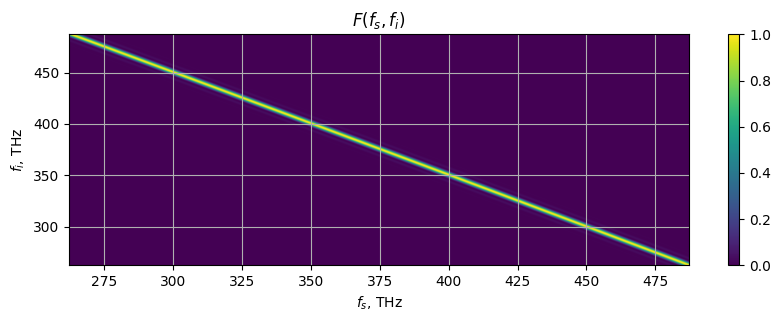

In [248]:
# ws, wi spectrum LBO

# 1) define pump wavelength and geometry
lambda_p = 400e-9        # pump central wavelength
delta_lambda_p = 5.5e-9  # pump fwhm
psi_BBO = np.deg2rad(29.77375182)  # BBO orientation
L = 20e-6                # pump coherence length instead of the nonlinear media length
Lgap = 0e-3              # common air gap
d = 0e-4                # additional dispersive medium length

# 2) build grids (signal frequency and internal angle in crystal)
omega_p = omega_from_lambda(lambda_p)
omega_s_nodes = np.linspace(0.35*omega_p, 0.65*omega_p, 1000)          # rad/s
omega_i_nodes = np.linspace(0.35*omega_p, 0.65*omega_p, 1000)          # rad/s

omega_s, omega_i = np.meshgrid(omega_s_nodes, omega_i_nodes, indexing="ij")
omega_p = np.full_like(omega_s, omega_p)

# 3) compute phase mismatch
# wavelengths
lam_p = lambda_from_omega(omega_p)
lam_s = lambda_from_omega(omega_s)
lam_i = lambda_from_omega(omega_i)

# indices, type-I e->oo
n_s_o = n_o_LBO(lam_s)
n_i_o = n_o_LBO(lam_i)
n_p_o = n_o_LBO(lam_p)
n_p_e = n_e_LBO(lam_p)
n_p_eff = n_eff(n_p_o, n_p_e, psi_LBO)

# n_s_air = n_air(lam_s)
# n_i_air = n_air(lam_i)
# n_p_air = n_air(lam_p)

# n_s_caco3 = n_o_caco3(lam_s)
# n_i_caco3 = n_o_caco3(lam_i)

# wavevectors
k_s_crystal = k(omega_s, n_s_o)
k_i_crystal = k(omega_i, n_i_o)
k_p_crystal = k(omega_p, n_p_eff)

# k_s_air = k(omega_s, n_s_air)
# k_i_air = k(omega_i, n_i_air)
# k_p_air = k(np.full_like(omega_s, omega_p), n_p_air)

# k_s_caco3 =k(omega_s, n_s_caco3)
# k_i_caco3 =k(omega_i, n_i_caco3)

# Δ in crystal: kp - ks cosθs - ks cosθi
Delta = k_p_crystal - k_s_crystal - k_i_crystal
delta = Delta*L

# signal angle in air gap from Snellius law: n_o*sin(theta_crystal) = n_air*sin(theta_air)
# theta_s_air, _ = snell_theta(n_s_o, theta_s, n_s_air)

# idler angle in air from transverse matching in air
# sin_ti_air = (k_s_air/k_i_air) * np.sin(theta_s_air)
# theta_i_air = np.asin(sin_ti_air)

# Δ in air
# Delta_a = k_p_air - k_s_air*np.cos(theta_s_air) - k_i_air*np.cos(theta_i_air)
# delta_a = Delta_a * Lgap

# signal angle in CaCO3: n_air*sin(theta_air) = n_caco3*sin(theta_caco3)
# theta_s_caco3, _ = snell_theta(n_s_air, theta_s_air, n_s_caco3)

# idler angle in CaCO3 from transverse matching
# sin_ti_caco3 = (k_s_caco3/k_i_caco3) * np.sin(theta_s_caco3)
# theta_i_caco3 = np.asin(sin_ti_caco3)

# Δ in CaCO3
# подобрать длину пробега накачки: x
# x = d
# delta_caco3 = k_p_air*x - k_s_caco3*np.cos(theta_s_caco3)*d - k_i_caco3*np.cos(theta_i_caco3)*d

# 4) compute instensity
delta_omega_p = (2 * np.pi * c0 / lambda_p**2) * delta_lambda_p
F = ( np.exp(-(omega_s + omega_i - omega_p)**2/(2*delta_omega_p**2)) * sinc(delta/2) * np.cos(1/2 * delta) )**2
F = F / F.max()

# 5) plot
plt.figure(figsize=(10, 3))
plt.imshow(F, origin="lower", aspect="auto",
           extent=np.array([
               omega_s_nodes[0]/(2*np.pi)/1e12,
               omega_s_nodes[-1]/(2*np.pi)/1e12,
               omega_i_nodes[0]/(2*np.pi)/1e12,
               omega_i_nodes[-1]/(2*np.pi)/1e12
           ]))
plt.xlabel(r"$f_s$, THz")
plt.ylabel(r"$f_i$, THz")
plt.title(r"$F(f_s, f_i)$")
plt.colorbar()
plt.grid()
plt.show()

Enter number of computational nodes: 1000
Enter number of display nodes: 1000
Enter BBO length [m]: 
Enter air gap [m]: 
Enter CaCO3 length [m]: 


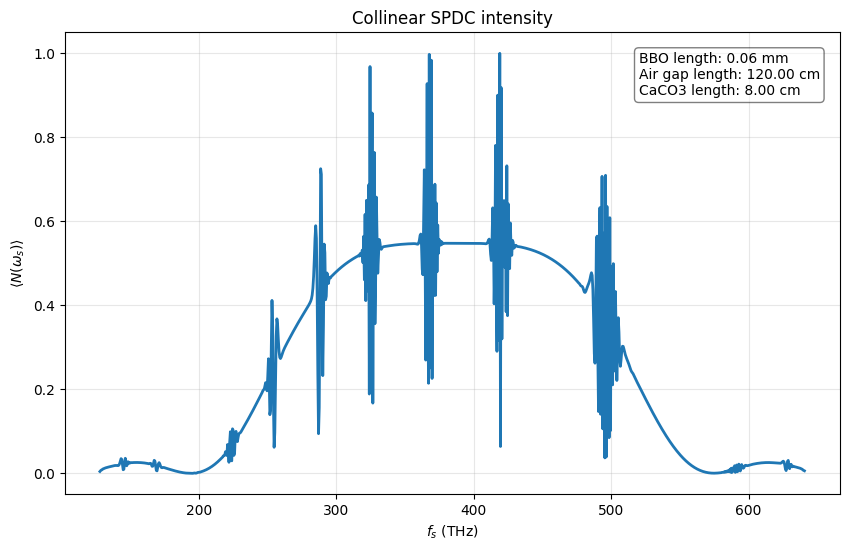

In [163]:
# ws, wi spectrum BBO
comp_nodes_number = int(input("Enter number of computational nodes:") or 8000)
disp_nodes_number = int(input("Enter number of display nodes:") or 8000)

# 1) define pump wavelength and geometry
lambda_p = 390e-9        # pump central wavelength
delta_lambda_p = 3e-9  # pump fwhm
duration_p = 60e-15  # pump duration
psi_BBO = np.deg2rad(90-29.77375182)  # BBO orientation
L = float(input("Enter BBO length [m]:") or 60e-6)                # pump coherence length instead of the nonlinear media length
Lgap = float(input("Enter air gap [m]:") or 120e-2)              # common air gap
d = float(input("Enter CaCO3 length [m]:") or 8e-2)                # additional dispersive medium length

# 2) build grids (signal frequency and internal angle in crystal)
omega_p = omega_from_lambda(lambda_p)
# omega_s_nodes = np.linspace(0.35*omega_p, 0.65*omega_p, 1000)          # rad/s
# omega_i_nodes = np.linspace(0.35*omega_p, 0.65*omega_p, 1000)          # rad/s
omega_s_nodes = np.linspace(0.5*omega_p - 2/6*omega_p, 0.5*omega_p + 2/6*omega_p, disp_nodes_number)          # rad/s
omega_i_nodes = np.linspace(0.5*omega_p - 2/6*omega_p, 0.5*omega_p + 2/6*omega_p, comp_nodes_number)          # rad/s

omega_s_2d, omega_i_2d = np.meshgrid(omega_s_nodes, omega_i_nodes, indexing="xy")
# omega_p_2d = np.full_like(omega_s, omega_p)
omega_p_2d = omega_s_2d + omega_i_2d

# 3) compute phase mismatch
# wavelengths
lam_p_2d = lambda_from_omega(omega_p_2d)
lam_s_2d = lambda_from_omega(omega_s_2d)
lam_i_2d = lambda_from_omega(omega_i_2d)

# indices, type-I e->oo
n_s_o = n_o_BBO(lam_s_2d)
n_i_o = n_o_BBO(lam_i_2d)
n_p_o = n_o_BBO(lam_p_2d)
n_p_e = n_e_BBO(lam_p_2d)
n_p_eff = n_eff(n_p_o, n_p_e, psi_BBO)

n_s_air = n_air(lam_s_2d)
n_i_air = n_air(lam_i_2d)
n_p_air = n_air(lam_p_2d)

n_s_caco3 = n_o_caco3(lam_s_2d)
n_i_caco3 = n_o_caco3(lam_i_2d)
n_p_caco3 = n_o_caco3(lam_p_2d)

# wavevectors
k_s_crystal = k(omega_s_2d, n_s_o)
k_i_crystal = k(omega_i_2d, n_i_o)
k_p_crystal = k(omega_p_2d, n_p_eff)
# k_p_crystal = k(omega_s_2d + omega_i_2d, n_p_eff)

k_s_air = k(omega_s_2d, n_s_air)
k_i_air = k(omega_i_2d, n_i_air)
k_p_air = k(omega_p_2d, n_p_air)

k_s_caco3 =k(omega_s_2d, n_s_caco3)
k_i_caco3 =k(omega_i_2d, n_i_caco3)

# Δ in crystal: kp - ks cosθs - ks cosθi
Delta = k_p_crystal - k_s_crystal - k_i_crystal
delta = Delta*L

# Δ in air
Delta_a = k_p_air - k_s_air - k_i_air
delta_a = Delta_a * Lgap

# Δ in CaCO3
da = n_o_caco3(lambda_p) * d / n_air(lambda_p)
delta_caco3 = k_p_air*da - k_s_caco3*d - k_i_caco3*d

# 4) compute instensity
delta_omega_p = (2*np.pi*c0/lambda_p**2) * delta_lambda_p
sigma_omega_p = delta_omega_p / (2*np.sqrt(2*np.log(2)))
F = (
    np.exp(-(omega_p_2d - omega_p)**2/(2*sigma_omega_p**2)) * 
    np.sinc(1/np.pi * delta/2) * 
    np.cos(1/2 * (delta + delta_a + delta_caco3))
)**2
# F = ( np.sinc(1/np.pi * delta/2) )**2
F = F / F.max()

# 5) plot
# ---------- helpers ----------
to_THz = lambda w: w / (2*np.pi) / 1e12  # angular freq → THz

fs_2d = to_THz(omega_s_2d)
fi_2d = to_THz(omega_i_2d)

fs_nodes = to_THz(omega_s_nodes)
fi_nodes = to_THz(omega_i_nodes)

extent = [fs_nodes[0], fs_nodes[-1], fi_nodes[0], fi_nodes[-1]]

# 1D marginal (integrate over idler)
angular_deg_spdc = np.trapezoid(F, omega_i_nodes, axis=0)

# # ---------- figure ----------
# fig, axs = plt.subplots(
#     1, 2, figsize=(11, 4.8),
#     gridspec_kw={"width_ratios": [1.35, 1]},
#     constrained_layout=True
# )

# # ==========================================================
# # (A) 2D Joint spectrum + phase matching overlay
# # ==========================================================
# ax = axs[0]

# im = ax.imshow(
#     F,
#     origin="lower",
#     aspect="auto",
#     extent=extent
# )

# # Phase matching (Δk = 0)
# # ax.contour(fs_2d, fi_2d, delta,
# #            levels=[0.0],
# #            linewidths=1,
# #            colors="black",
# #            linestyles="--")

# # # Energy conservation (ωs + ωi = ωp)
# # ax.contour(fs_2d, fi_2d, omega_p_2d - omega_p,
# #            levels=[0.0],
# #            linewidths=1,
# #            colors="red",
# #            linestyles="--")

# ax.set_xlabel(r"$f_s$, THz")
# ax.set_ylabel(r"$f_i$, THz")
# ax.set_title(r"$g(f_s, f_i)$ with phase matching")

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label("Intensity")

# # ==========================================================
# # (B) 1D spectrum
# # ==========================================================
# ax = axs[1]

# ax.plot(fs_nodes, angular_deg_spdc/angular_deg_spdc.max(), lw=2)
# ax.set_xlabel(r"$f_s$ (THz)")
# ax.set_ylabel(r"$\langle N(\omega_s) \rangle$")
# ax.set_title(f"Collinear SPDC intensity ({nodes_number} comp. nodes)")
# ax.grid(True, alpha=0.3)

# plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fs_nodes, angular_deg_spdc/angular_deg_spdc.max(), lw=2)
ax.set_xlabel(r"$f_s$ (THz)")
ax.set_ylabel(r"$\langle N(\omega_s) \rangle$")
ax.set_title(f"Collinear SPDC intensity")
ax.grid(True, alpha=0.3)

setup_info = '\n'.join([
    r'BBO length: %.2f mm' % (L*1e3, ),
    r'Air gap length: %.2f cm' % (Lgap*1e2, ),
    r'CaCO3 length: %.2f cm' % (d*1e2, )
])
box = dict(boxstyle='round', facecolor='white', alpha=0.5)
ax.text(520, 0.9, setup_info, bbox=box)

# comp_info = '\n'.join([
#     r'Computational nodes: %.0i' % (comp_nodes_number, ),
#     r'Display nodes: %.0i' % (disp_nodes_number, ),
# ])
# box = dict(boxstyle='round', facecolor='white', alpha=0.5)
# ax.text(520, 0.7, comp_info, bbox=box)

plt.show()